# F1 - Definición del Proyecto Titanic

## 1. Contexto del problema

El hundimiento del Titanic es un caso clásico para aplicar análisis de datos, ya que permite estudiar cómo distintas características de los pasajeros pudieron influir en la supervivencia.

Este proyecto busca analizar el conjunto de datos Titanic para identificar patrones asociados a la supervivencia, considerando variables como sexo, edad, clase del pasajero, tarifa pagada y puerto de embarque.

## 2. Objetivo general

Analizar los factores que influyeron en la supervivencia de los pasajeros del Titanic mediante técnicas de análisis exploratorio de datos y preparación para modelamiento predictivo.

## 3. Objetivos específicos

- Cargar y revisar el dataset Titanic.
- Identificar variables relevantes para el análisis.
- Evaluar la calidad inicial de los datos.
- Detectar valores nulos o inconsistentes.
- Preparar la base para una fase posterior de limpieza, visualización y modelamiento.

## 4. Descripción del dataset

El dataset contiene información de 891 pasajeros del Titanic y 12 variables.

La variable objetivo es `Survived`, donde:

- `0` indica que el pasajero no sobrevivió.
- `1` indica que el pasajero sobrevivió.

Algunas variables explicativas son:

- `Pclass`: clase del pasajero.
- `Sex`: sexo.
- `Age`: edad.
- `SibSp`: familiares directos a bordo.
- `Parch`: padres o hijos a bordo.
- `Fare`: tarifa pagada.
- `Embarked`: puerto de embarque.

## 5. Carga de librerías y datos
En esta sección se importan las librerías principales y se carga el archivo CSV ubicado en la carpeta `data/raw`.

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Titanic-Dataset.csv")
print(df.shape)

df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



## 6. Revisión inicial del dataset

Se revisa el tamaño del conjunto de datos para conocer cuántos registros y variables contiene.

In [3]:
print(df.shape)

(891, 12)


## 7. Información general de las variables

Se revisan los tipos de datos y la presencia inicial de valores nulos.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Valores nulos detectados

La revisión inicial muestra valores nulos principalmente en las variables `Age`, `Cabin` y `Embarked`.

Esto será tratado en la siguiente fase del proyecto, correspondiente al análisis exploratorio y limpieza de datos.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

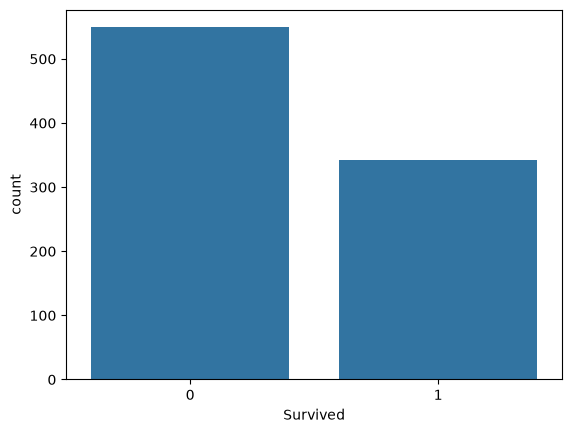

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Survived")
plt.show()

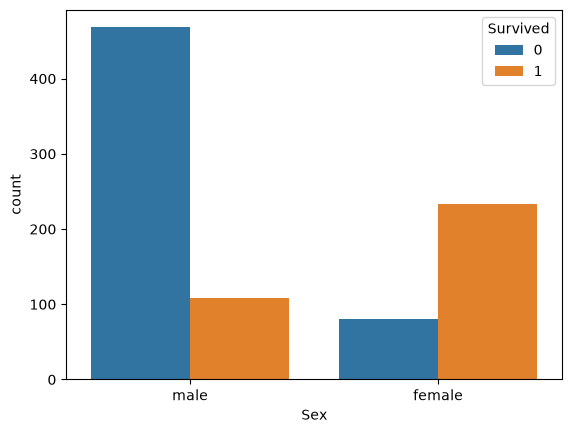

In [8]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.show()


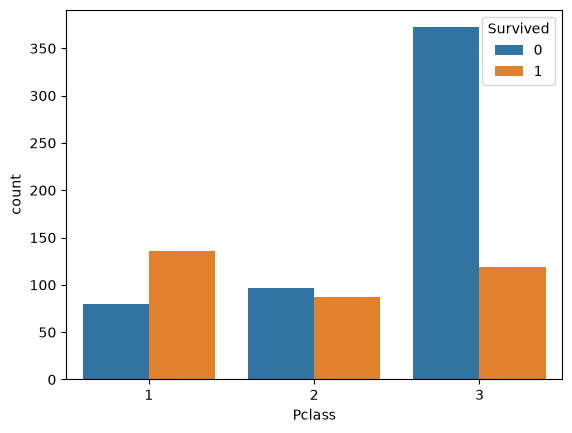

In [9]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.show()

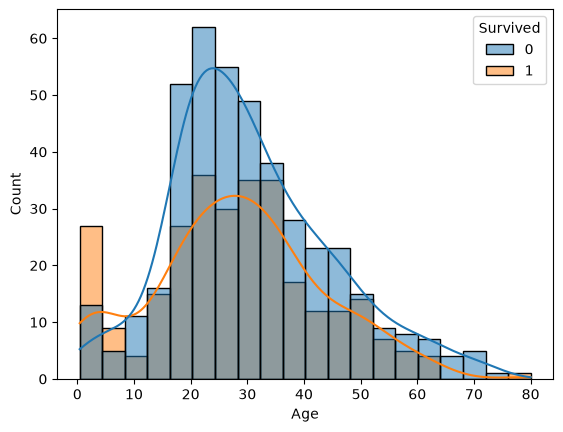

In [10]:
sns.histplot(data=df, x="Age", hue="Survived", kde=True)
plt.show()

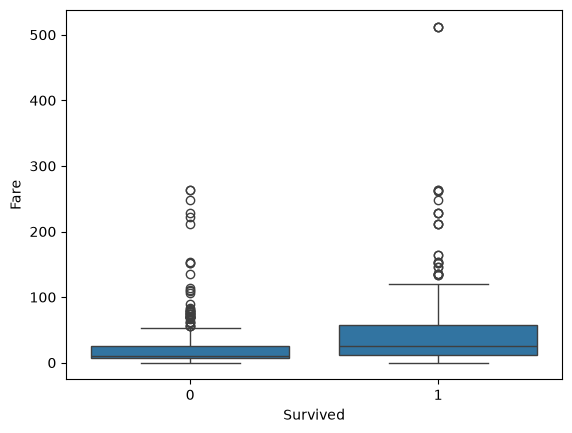

In [11]:
sns.boxplot(data=df, x="Survived", y="Fare")
plt.show()

In [13]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [15]:
df = df.drop("Cabin", axis=1)

In [16]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 9. Conclusión de la Fase 1

En esta primera fase se definió el problema, el objetivo del análisis y se realizó una exploración inicial del dataset Titanic.

El conjunto de datos contiene 891 registros y 12 variables. La variable objetivo será `Survived`, mientras que variables como `Sex`, `Age`, `Pclass`, `Fare` y `Embarked` serán consideradas como posibles factores explicativos.

Se detectaron valores nulos en `Age`, `Cabin` y `Embarked`, por lo que en la siguiente fase se realizará la limpieza, tratamiento de datos faltantes y análisis exploratorio visual.